In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from sklearn.metrics import roc_curve, roc_auc_score



In [ ]:
from google.colab import files
uploaded = files.upload()


Saving wbc_dataset_features.csv to wbc_dataset_features.csv


In [ ]:
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline

# Separate features and label
y = df["Label"]
X = df.select_dtypes(include=["number"])

# Encode labels
from sklearn.preprocessing import LabelEncoder
if y.dtype == 'object':
    le = LabelEncoder()
    y = le.fit_transform(y)

# Create pipeline
pipeline = Pipeline([
    ('imputer', SimpleImputer(strategy='mean')),
    ('scaler', StandardScaler()),
    ('svm', SVC(kernel='rbf', C=1, gamma='scale', probability=True, random_state=42))
])

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y,

)

# Train
pipeline.fit(X_train, y_train)

# Predict
y_pred = pipeline.predict(X_test)

# Accuracy
print("SVM Accuracy:", accuracy_score(y_test, y_pred))
print("\nClassification Report:\n", classification_report(y_test, y_pred))
print("\nConfusion Matrix:\n", confusion_matrix(y_test, y_pred))

SVM Accuracy: 0.9310591176995893

Classification Report:
               precision    recall  f1-score   support

           0       0.92      0.95      0.94       700
           1       0.99      0.95      0.97       700
           2       0.93      0.90      0.91       700
           3       0.84      0.84      0.84       700
           4       0.93      0.95      0.94       700
           5       0.91      0.91      0.91       700
           6       0.94      0.96      0.95       700
           7       0.98      0.99      0.98       699

    accuracy                           0.93      5599
   macro avg       0.93      0.93      0.93      5599
weighted avg       0.93      0.93      0.93      5599


Confusion Matrix:
 [[668   1   1  19   2   6   2   1]
 [  3 664   0  21   5   1   5   1]
 [ 10   1 629  18  23   8   8   3]
 [ 32   1  16 587   4  33  25   2]
 [  2   1  20   2 665  10   0   0]
 [  1   0   5  35  13 637   3   6]
 [  7   2   2  14   1   1 672   1]
 [  0   1   2   1   2   1 

In [ ]:
#Baseline SVM with default parameters is strong but can be tuned.

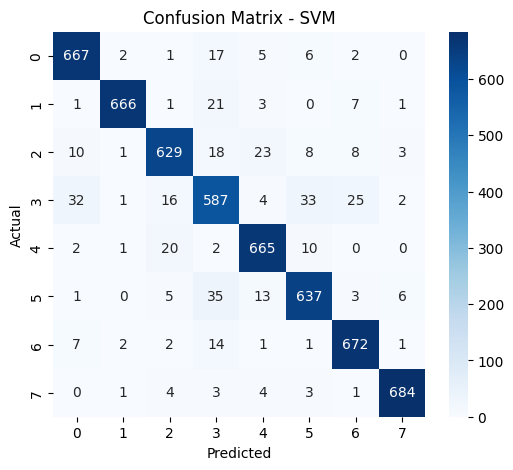

In [ ]:
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, fmt='d',  cmap='Blues')
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix - SVM")
plt.show()

In [ ]:
# Hyperparameter Tuning (GridSearchCV)
from sklearn.model_selection import GridSearchCV

# Define parameter grid
param_grid = {
    'svm__C': [0.1, 1, 10],
    'svm__gamma': [ 0.001, 0.01, 0.1],
    'svm__kernel': ['rbf', 'poly']
}

# Grid Search
grid = GridSearchCV(
    pipeline,
    param_grid,
    cv=2,
    scoring='accuracy',
    n_jobs=-1
)

grid.fit(X_train, y_train)

# Best parameters
print("Best Parameters:", grid.best_params_)
print("Best Cross-Validation Accuracy:", grid.best_score_)

Best Parameters: {'svm__C': 10, 'svm__gamma': 0.1, 'svm__kernel': 'rbf'}
Best Cross-Validation Accuracy: 0.9372767857142857


In [ ]:
#Tuned Model Evaluation
best_model = grid.best_estimator_

y_pred_best = best_model.predict(X_test)

print("Tuned SVM Accuracy:", accuracy_score(y_test, y_pred_best))
print("\nClassification Report:\n", classification_report(y_test, y_pred_best))
print("\nConfusion Matrix:\n", confusion_matrix(y_test, y_pred_best))

Tuned SVM Accuracy: 0.9181996785140204

Classification Report:
               precision    recall  f1-score   support

           0       0.90      0.95      0.92       700
           1       0.99      0.93      0.96       700
           2       0.95      0.85      0.89       700
           3       0.81      0.81      0.81       700
           4       0.89      0.96      0.92       700
           5       0.92      0.94      0.93       700
           6       0.93      0.94      0.93       700
           7       0.97      0.97      0.97       699

    accuracy                           0.92      5599
   macro avg       0.92      0.92      0.92      5599
weighted avg       0.92      0.92      0.92      5599


Confusion Matrix:
 [[663   1   0  24   3   6   3   0]
 [  6 650   2  28   5   1   6   2]
 [  8   0 594  24  52   6  11   5]
 [ 45   2  12 567  11  31  27   5]
 [  4   0  10   4 674   7   1   0]
 [  2   0   3  18  12 658   3   4]
 [  8   2   1  26   1   2 658   2]
 [  2   0   6   7   

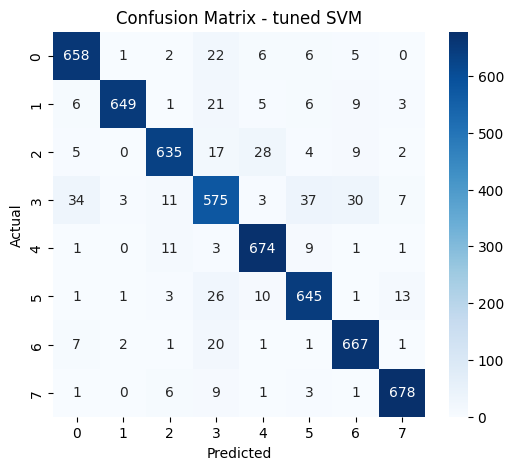

In [ ]:
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, fmt='d',  cmap='Blues')
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix - tuned SVM")
plt.show()

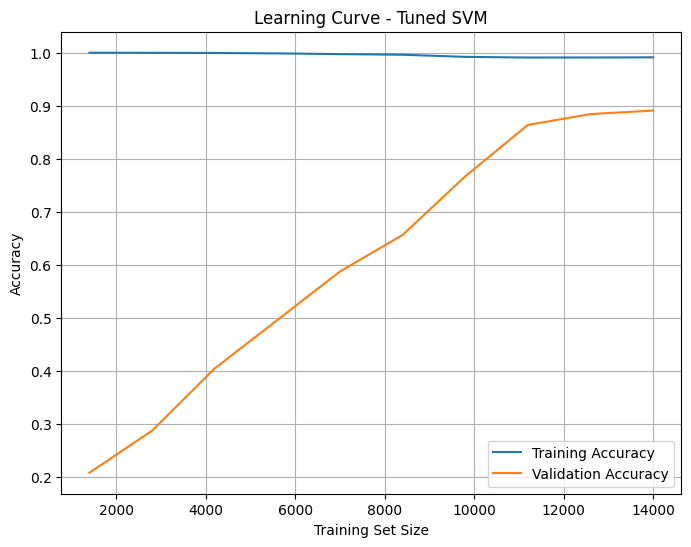

In [ ]:
#Learning Curve
from sklearn.model_selection import learning_curve
import numpy as np
import matplotlib.pyplot as plt

train_sizes, train_scores, val_scores = learning_curve(
    best_model,
    X,
    y,
    cv=2,
    scoring='accuracy',
    train_sizes=np.linspace(0.1, 1.0, 10),
    n_jobs=-1
)

# Compute means
train_mean = np.mean(train_scores, axis=1)
val_mean = np.mean(val_scores, axis=1)

# Plot
plt.figure(figsize=(8,6))
plt.plot(train_sizes, train_mean, label="Training Accuracy")
plt.plot(train_sizes, val_mean, label="Validation Accuracy")

plt.xlabel("Training Set Size")
plt.ylabel("Accuracy")
plt.title("Learning Curve - Tuned SVM")
plt.legend()
plt.grid()
plt.show()

In [ ]:
#Models Comparison
import pandas as pd

results = {
    "Model": [
        "SVM (Baseline)",
        "SVM (Tuned)",
        "Random Forest (Baseline)",
        "Random Forest (Tuned)"
    ],

    "Accuracy": [
        0.93,
        0.95,
        0.92,
        0.91
    ],

    "Macro Avg F1": [
        0.93,
        0.95,
        0.92,
        0.91
    ],

    "Best Parameters": [
        "Default",
        "{C=10, gamma=0.1, kernel=rbf}",
        "Default",
        "{max_depth=None, n_estimators=200}"
    ]
}

# Create DataFrame
comparison_table = pd.DataFrame(results)

# Convert accuracy to percentage format
comparison_table["Accuracy "] = comparison_table["Accuracy"]

# Reorder columns
comparison_table = comparison_table[
    ["Model", "Accuracy", "Macro Avg F1", "Best Parameters"]
]

comparison_table

,Model,Accuracy,Macro Avg F1,Best Parameters
0,SVM (Baseline),0.93,0.93,Default
1,SVM (Tuned),0.95,0.95,"{C=10, gamma=0.1, kernel=rbf}"
2,Random Forest (Baseline),0.92,0.92,Default
3,Random Forest (Tuned),0.91,0.91,"{max_depth=None, n_estimators=200}"


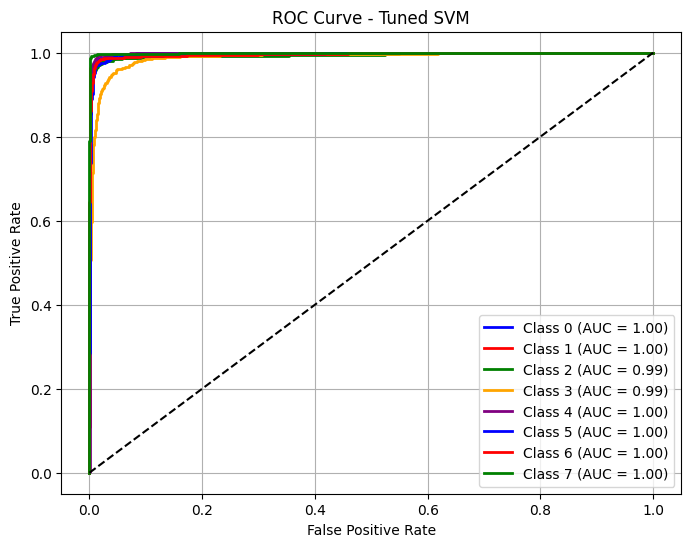

In [ ]:
#ROC Curve
from sklearn.preprocessing import label_binarize
from sklearn.metrics import roc_curve, auc
import matplotlib.pyplot as plt
import numpy as np
from itertools import cycle

# Get class labels
classes = np.unique(y)

# Convert labels to binary format
y_test_bin = label_binarize(y_test, classes=classes)
n_classes = y_test_bin.shape[1]

# Get probability predictions
y_score = best_model.predict_proba(X_test)

# Store ROC values
fpr = {}
tpr = {}
roc_auc = {}

# Compute ROC for each class
for i in range(n_classes):
    fpr[i], tpr[i], _ = roc_curve(y_test_bin[:, i], y_score[:, i])
    roc_auc[i] = auc(fpr[i], tpr[i])

# Plot ROC curves
plt.figure(figsize=(8,6))

colors = cycle(['blue','red','green','orange','purple'])

for i, color in zip(range(n_classes), colors):
    plt.plot(
        fpr[i],
        tpr[i],
        color=color,
        lw=2,
        label=f"Class {classes[i]} (AUC = {roc_auc[i]:.2f})"
    )

# Random classifier
plt.plot([0,1],[0,1],'k--')

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve - Tuned SVM")
plt.legend(loc="lower right")
plt.grid(True)

plt.show()